# Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DEMAND_PATH = 'demand_data.csv'
WEATHER_PATH = 'weather_data.csv'
ECO_PATH = 'economic_full_1.csv'

In [2]:
df = pd.read_excel('PGCB_date_power_demand.xlsx')
wea = pd.read_excel('weather_data.xlsx',skiprows=3)
eco = pd.read_csv('economic_full_1.csv')

# Data Cleaning and Integration

In [3]:
df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [4]:
df.describe()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal
count,92650,9.265000e+04,92650.000000,92650.000000,92650.000000,9.265000e+04,92650.000000,92650.000000,70517.000000,18676.000000,92650.000000,92650.000000,7338.000000,5351.000000
mean,2020-05-17 03:52:07.609282304,9.429376e+03,8819.646044,81.470405,5120.782914,2.038257e+03,974.349768,96.899007,46.224101,9.233133,663.169261,93.616773,881.196375,0.546814
min,2015-04-19 00:00:00,7.300000e+01,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-10-31 06:15:00,6.814775e+03,6812.250000,0.000000,4419.000000,7.200000e+02,159.000000,40.000000,0.000000,0.000000,465.000000,70.000000,702.000000,0.000000
50%,2020-05-21 15:30:00,8.412000e+03,8422.000000,0.000000,5022.000000,1.535000e+03,401.000000,79.000000,0.000000,4.000000,705.000000,97.000000,822.000000,0.000000
75%,2022-12-03 18:22:30,1.055600e+04,10633.000000,0.000000,5812.000000,2.462000e+03,1220.000000,150.000000,25.000000,13.000000,910.000000,126.000000,1050.750000,0.000000
max,2025-06-17 12:00:00,6.452650e+07,156050.000000,65359.000000,74818.000000,2.922290e+07,31687.000000,5623.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000
std,NaN,2.119759e+05,2772.150108,442.757182,1138.938147,9.608105e+04,1226.515481,71.442697,106.410644,16.272517,349.609395,47.483221,369.905673,4.525897


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal           

In [6]:
#Rounding off the datetime from .5 hours to complete hours
df['datetime'] = df['datetime'].dt.round('h')

#Dropping the duplicates
df = df.drop_duplicates()

#Setting datetime as the index to use in integrating other data
df.set_index('datetime', inplace=True)

#Sorting the data w.r.t. time
df = df.sort_index()

In [7]:
#Filling these with 0 assuming they weren't operational before the time they have non-nan values
df['india_adani']=df['india_adani'].fillna(0)
df['nepal'] = df['nepal'].fillna(0)
df['solar'] = df['solar'].fillna(0)
df['wind'] = df['wind'].fillna(0)

<Axes: title={'center': 'Demand before cleaning'}, xlabel='datetime'>

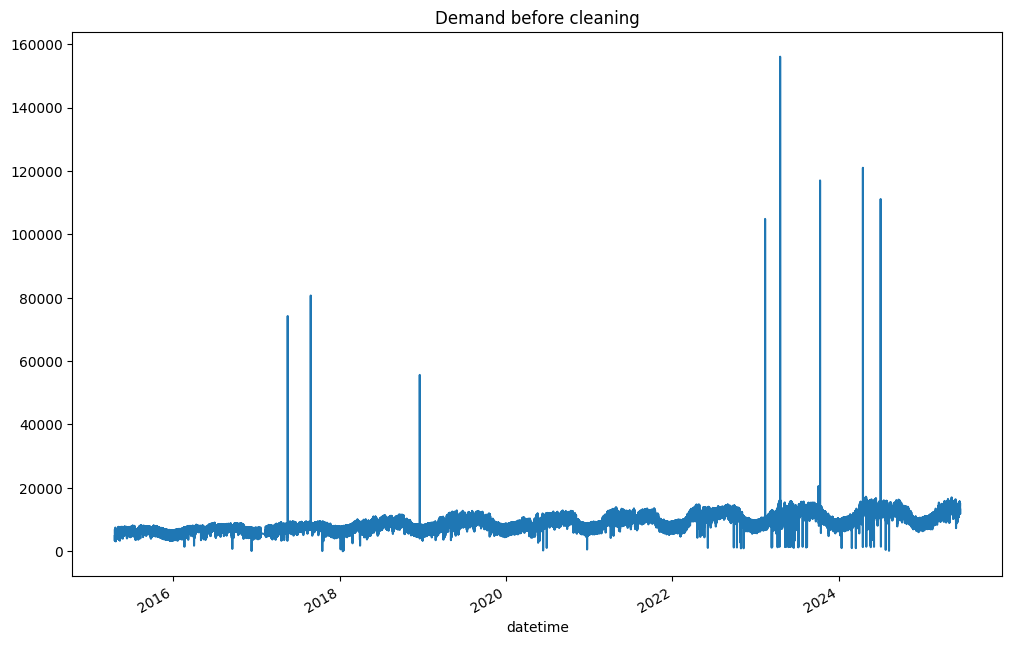

In [8]:
df['demand_mw'].plot(figsize=(12,8),title='Demand before cleaning')

In [9]:
#Using interpolation to fill NaN values with Z-score and MAD
for col in df.columns:
  if col!='remarks':
    median = df[col].median()
    mad = np.median(np.abs(df[col] - median))

    if mad != 0:
        mod_z = 0.6745 * (df[col] - median) / mad
        df.loc[mod_z.abs() > 3, col] = np.nan
        df[col] = df[col].interpolate(method='linear', limit_direction='both')
        df[col] = df[col].ffill().bfill()

<Axes: title={'center': 'Demand after cleaning'}, xlabel='datetime'>

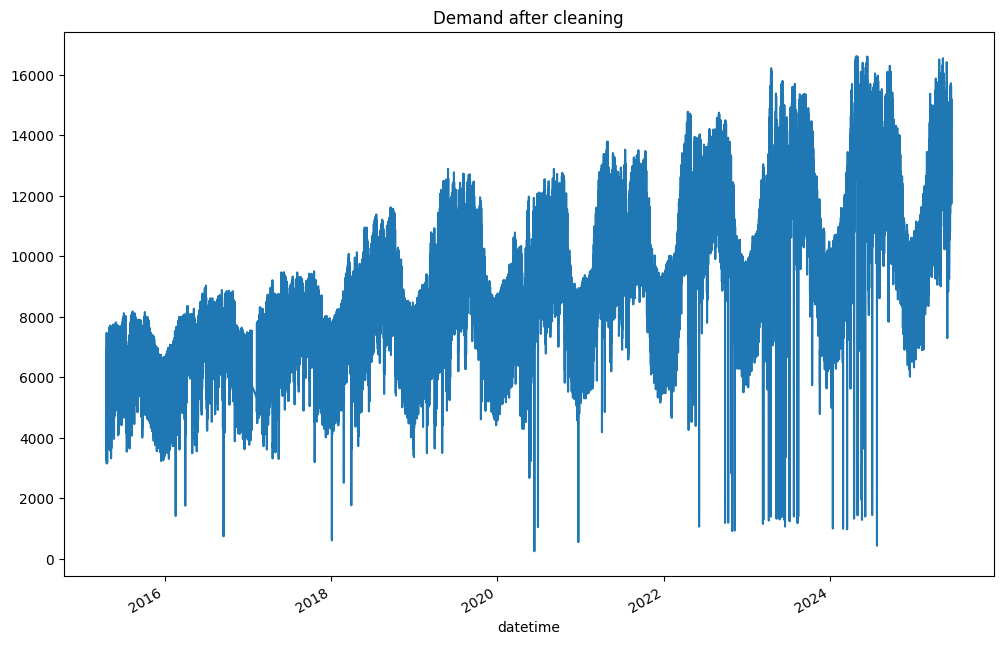

In [10]:
df['demand_mw'].plot(figsize=(12,8),title='Demand after cleaning')

In [11]:
#Setting time as inddex to integrate, sorting w.r.t. time and dropping the duplicate rows
wea = wea.set_index('time')
wea = wea.sort_index()
wea = wea.drop_duplicates()

In [12]:
wea.head()

,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
time,,,,,,,,,
2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [13]:
wea.describe()

,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
count,107302.000000,107302.000000,107302.000000,107302.000000,107302.000000,107302.000000,107302.000000,107302.000000,107302.000000
mean,25.457468,76.806164,28.804467,0.205424,20.633152,26.769724,195.690630,50.729241,1386.510429
std,5.033031,16.454831,6.905302,0.895581,5.231154,4.908620,94.451951,42.470621,1704.215251
min,8.400000,15.000000,6.600000,0.000000,2.500000,11.700000,1.000000,0.000000,0.000000
25%,22.600000,67.000000,24.200000,0.000000,15.800000,23.800000,136.000000,3.000000,0.000000
50%,26.500000,81.000000,30.800000,0.000000,22.800000,27.600000,180.000000,49.000000,0.000000
75%,28.800000,90.000000,33.700000,0.000000,25.200000,29.900000,286.000000,98.000000,3600.000000
max,40.800000,100.000000,45.600000,43.800000,28.600000,44.500000,360.000000,100.000000,3600.000000


In [14]:
wea.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 107302 entries, 2014-01-01 00:00:00 to 2026-03-29 23:00:00
Data columns (total 9 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   temperature_2m (°C)             107302 non-null  float64
 1   relative_humidity_2m (%)        107302 non-null  int64  
 2   apparent_temperature (°C)       107302 non-null  float64
 3   precipitation (mm)              107302 non-null  float64
 4   dew_point_2m (°C)               107302 non-null  float64
 5   soil_temperature_0_to_7cm (°C)  107302 non-null  float64
 6   wind_direction_10m (°)          107302 non-null  int64  
 7   cloud_cover (%)                 107302 non-null  int64  
 8   sunshine_duration (s)           107302 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 8.2 MB


In [15]:
#Choosing the only features that matter from eco df
need = ['NY.GDP.MKTP.KD.ZG','SP.POP.TOTL','NV.IND.TOTL.ZS','FP.CPI.TOTL.ZG','EG.USE.PCAP.KG.OE','EG.EGY.PRIM.PP.KD']
eco = eco[eco['Indicator Code'].isin(need)]
eco = eco.set_index('Indicator Name')
eco =  eco.drop('Country Name',axis=1)
eco = eco.drop('Indicator Code',axis=1)

#Transposing the df to get the year as row labels
eco = eco.T

#Using linear interpolation to fill the NaNs
for col in eco.columns:
  if eco[col].isna().any():
    eco[col].interpolate(method='linear',limit_direction='both')
    eco[col] = eco[col].ffill().bfill()

In [16]:
eco.head()

Indicator Name,"Inflation, consumer prices (annual %)",Energy use (kg of oil equivalent per capita),"Population, total",GDP growth (annual %),"Industry (including construction), value added (% of GDP)",Energy intensity level of primary energy (MJ/$2021 PPP GDP)
1960,9.874696,114.239336,51828660.0,6.058161,6.973816,2.45
1961,9.874696,114.239336,53310348.0,6.058161,6.794118,2.45
1962,9.874696,114.239336,54881146.0,5.453031,7.963862,2.45
1963,9.874696,114.239336,56504402.0,-0.455894,7.804593,2.45
1964,9.874696,114.239336,58178374.0,10.952789,10.423024,2.45


In [17]:
eco.describe()

Indicator Name,"Inflation, consumer prices (annual %)",Energy use (kg of oil equivalent per capita),"Population, total",GDP growth (annual %),"Industry (including construction), value added (% of GDP)",Energy intensity level of primary energy (MJ/$2021 PPP GDP)
count,66.000000,66.000000,6.600000e+01,66.000000,66.000000,66.000000
mean,7.931667,156.884953,1.152906e+08,4.426236,20.482774,2.355909
std,2.434145,61.364318,3.841659e+07,3.593744,7.954010,0.180989
min,2.007174,110.466567,5.182866e+07,-13.973729,6.064102,1.900000
25%,6.060784,114.239336,8.035830e+07,3.557021,14.344585,2.330000
50%,9.490841,115.676206,1.170423e+08,5.099283,21.700904,2.450000
75%,9.874696,185.843631,1.505239e+08,6.363549,24.899108,2.450000
max,11.395165,297.118356,1.735624e+08,10.952789,34.594272,2.580000


In [18]:
eco.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66 entries, 1960 to 2025
Data columns (total 6 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Inflation, consumer prices (annual %)                        66 non-null     float64
 1   Energy use (kg of oil equivalent per capita)                 66 non-null     float64
 2   Population, total                                            66 non-null     float64
 3   GDP growth (annual %)                                        66 non-null     float64
 4   Industry (including construction), value added (% of GDP)    66 non-null     float64
 5   Energy intensity level of primary energy (MJ/$2021 PPP GDP)  66 non-null     float64
dtypes: float64(6)
memory usage: 5.7+ KB


In [19]:
#Integrating weather into demand df
wea.index.name = 'datetime'
df = df.join(wea, how='left')

In [20]:
#Integrating eco into demand df
df['Year'] = df.index.year          #Issues with integrating straightaway with year as index of eco
eco.index = eco.index.astype(int)
df = pd.merge(df, eco, left_on='Year', right_index=True, how='left')
df = df.drop(columns=['Year'])
df.index = pd.to_datetime(df.index)

In [21]:
#Cleaning the df's column names as LightGBM can't have special characters in feature names
import re

def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^a-zA-Z0-9_]', '_', col)
        new_col = re.sub(r'_{2,}', '_', new_col)
        new_col = new_col.strip('_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

df = clean_col_names(df)
print("Cleaned DataFrame Columns:")
print(df.columns)

Cleaned DataFrame Columns:
Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks', 'temperature_2m_C',
       'relative_humidity_2m', 'apparent_temperature_C', 'precipitation_mm',
       'dew_point_2m_C', 'soil_temperature_0_to_7cm_C', 'wind_direction_10m',
       'cloud_cover', 'sunshine_duration_s',
       'Inflation_consumer_prices_annual',
       'Energy_use_kg_of_oil_equivalent_per_capita', 'Population_total',
       'GDP_growth_annual',
       'Industry_including_construction_value_added_of_GDP',
       'Energy_intensity_level_of_primary_energy_MJ_2021_PPP_GDP'],
      dtype='object')


# Feature Engineering


In [22]:
#Dropping unnecessary columns
df = df.drop(['remarks','temperature_2m_C','wind_direction_10m', 'cloud_cover','Industry_including_construction_value_added_of_GDP','soil_temperature_0_to_7cm_C','india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'gas', 'liquid_fuel','generation_mw',
       'coal', 'hydro', 'solar', 'wind','Inflation_consumer_prices_annual',
       'Energy_use_kg_of_oil_equivalent_per_capita', 'Population_total',
       'GDP_growth_annual',
       'Energy_intensity_level_of_primary_energy_MJ_2021_PPP_GDP'],axis=1)
#Turns out the model doesn't use these economic data much (maybe as the prediction mostly depends on the prev hour, day and weekly data not yearly) hence dropped

In [23]:
#Temporal features
df['hour']=df.index.hour
df['dayofweek']=df.index.day_of_week
df['dayofweek_sin']=np.sin(2*np.pi*df['dayofweek']/7)
df['dayofweek_cos']=np.cos(2*np.pi*df['dayofweek']/7)
df['month']=df.index.month
df['month_sin']=np.sin(2*np.pi*df['month']/12)
df['month_cos']=np.cos(2*np.pi*df['month']/12)
df['weekend']=df['dayofweek'].isin([5,6]).astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['is_peak_hour'] = df['hour'].isin([10,11,12,18,19,20]).astype(int)
df['temp_high'] = (df['apparent_temperature_C'] > 30).astype(int)
df['temp_low'] = (df['apparent_temperature_C'] < 15).astype(int)
df['humid_temp'] = df['relative_humidity_2m'] * df['apparent_temperature_C'] / 100
df['temp_abs_deviation'] = np.abs(df['apparent_temperature_C'] - 25)  # Assume 25°C is "neutral"

#Lag features and trends
df['lag_1'] = df['demand_mw'].shift(1)
df['lag_24'] = df['demand_mw'].shift(24)
df['lag_168'] = df['demand_mw'].shift(168)
df['demand_trend'] = (df['demand_mw'].shift(1) - df['demand_mw'].shift(25)) / 24
df['demand_volatility_24h'] = df['demand_mw'].shift(1).rolling(24).std()
df['demand_momentum'] = df['demand_mw'].shift(1) - df['demand_mw'].shift(2)

#Rolling features
df['ewma_4h'] = df['demand_mw'].shift(1).ewm(span=4, adjust=False).mean()       #EWMA gave better results than rolling mean
df['ewma_24h'] = df['demand_mw'].shift(1).ewm(span=24, adjust=False).mean()
df['roll_std_24'] = df['demand_mw'].shift(1).rolling(24).std()

#Target values
df['target'] = df['demand_mw'].shift(-1)

#Dropping variables whose temporal features have been made
df = df.drop(['dayofweek','month','hour'],axis=1)

df = df.dropna()

In [24]:
df.columns

Index(['demand_mw', 'load_shedding', 'relative_humidity_2m',
       'apparent_temperature_C', 'precipitation_mm', 'dew_point_2m_C',
       'sunshine_duration_s', 'dayofweek_sin', 'dayofweek_cos', 'month_sin',
       'month_cos', 'weekend', 'hour_sin', 'hour_cos', 'is_peak_hour',
       'temp_high', 'temp_low', 'humid_temp', 'temp_abs_deviation', 'lag_1',
       'lag_24', 'lag_168', 'demand_trend', 'demand_volatility_24h',
       'demand_momentum', 'ewma_4h', 'ewma_24h', 'roll_std_24', 'target'],
      dtype='object')

<Axes: >

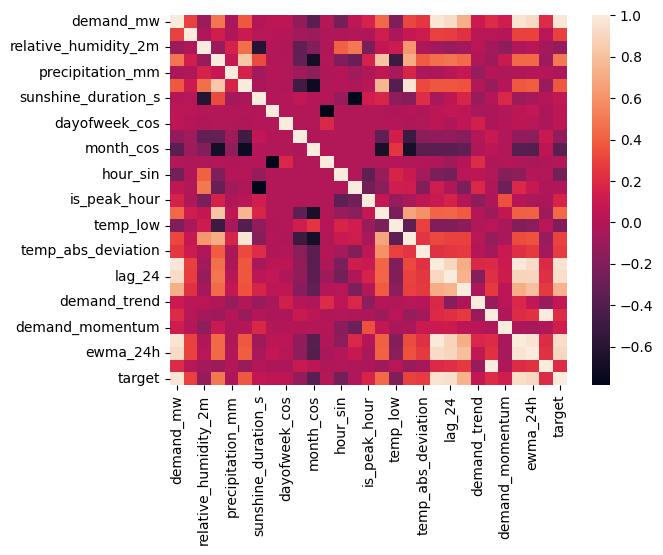

In [25]:
corr = df.corr()
sns.heatmap(corr)

# Training


In [26]:
#Test-Train splitting
split_date = '2024-01-01'

train_df = df[df.index < split_date]
val_df   = df[df.index >= split_date]

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

X_val = val_df.drop(columns=['target'])
y_val = val_df['target']

In [27]:
#Use this cell only to tune again, else use the already tuned best_params

!pip install optuna
import optuna
from sklearn.metrics import mean_absolute_percentage_error
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "num_leaves": trial.suggest_int("num_leaves", 2, 256),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity" : -1
    }

    model = LGBMRegressor(**params)

    tscv = TimeSeriesSplit(n_splits=5)
    mape_scores = []

    for train_index, val_index in tscv.split(X_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        model.fit(X_train_fold, y_train_fold)
        preds_fold = model.predict(X_val_fold)
        mape_scores.append(mean_absolute_percentage_error(y_val_fold, preds_fold))

    return np.mean(mape_scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)
print(f"best params: {study.best_params}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.8 MB/s eta 0:00:00


[I 2026-04-23 16:55:33,667] A new study created in memory with name: no-name-3770268d-c8af-4395-a233-d48b798d4980
[I 2026-04-23 16:56:14,006] Trial 0 finished with value: 0.03478167313483786 and parameters: {'n_estimators': 991, 'max_depth': 8, 'num_leaves': 207, 'learning_rate': 0.11351196207818434, 'subsample': 0.7393407306979314, 'colsample_bytree': 0.8805584330306235}. Best is trial 0 with value: 0.03478167313483786.
[I 2026-04-23 16:56:30,607] Trial 1 finished with value: 0.036363098548244474 and parameters: {'n_estimators': 486, 'max_depth': 8, 'num_leaves': 245, 'learning_rate': 0.1349009328444561, 'subsample': 0.6588899550686975, 'colsample_bytree': 0.584391261285165}. Best is trial 0 with value: 0.03478167313483786.
[I 2026-04-23 16:56:55,338] Trial 2 finished with value: 0.035433910025306506 and parameters: {'n_estimators': 699, 'max_depth': 8, 'num_leaves': 72, 'learning_rate': 0.16442065861522645, 'subsample': 0.6277796991617266, 'colsample_bytree': 0.857693228046386}. Best

best params: {'n_estimators': 680, 'max_depth': 8, 'num_leaves': 10, 'learning_rate': 0.11291399451070712, 'subsample': 0.5736263742244695, 'colsample_bytree': 0.9471080238216911}


In [28]:
best_params=study.best_params
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
best_model = LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

feature_importances = best_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
0,demand_mw,686
12,hour_sin,578
13,hour_cos,456
20,lag_24,423
22,demand_trend,398
24,demand_momentum,384
19,lag_1,358
21,lag_168,309
1,load_shedding,291
5,dew_point_2m_C,279


# Results

<Axes: ylabel='Feature'>

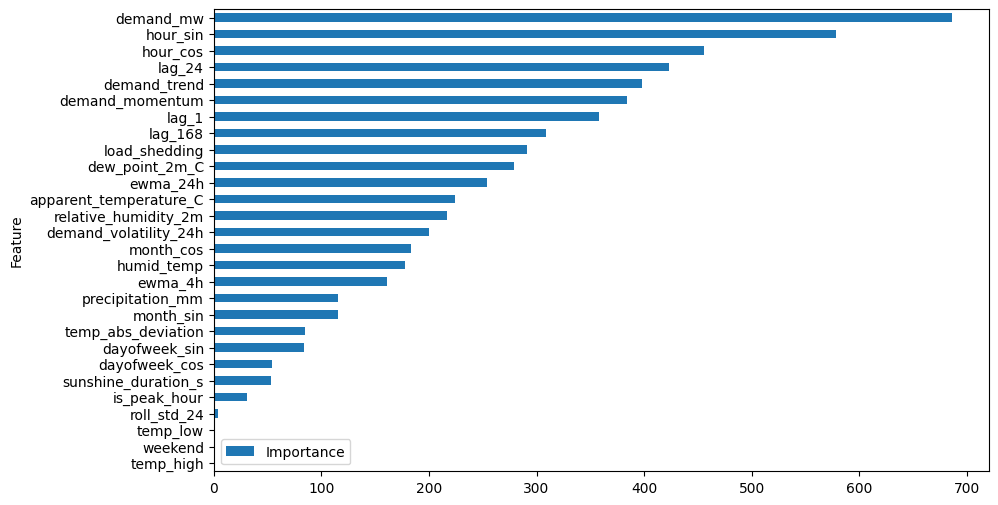

In [29]:
importance_df = importance_df.sort_values(by='Importance',ascending=True)
importance_df.plot(kind='barh', x='Feature', y='Importance', figsize=(10, 6))

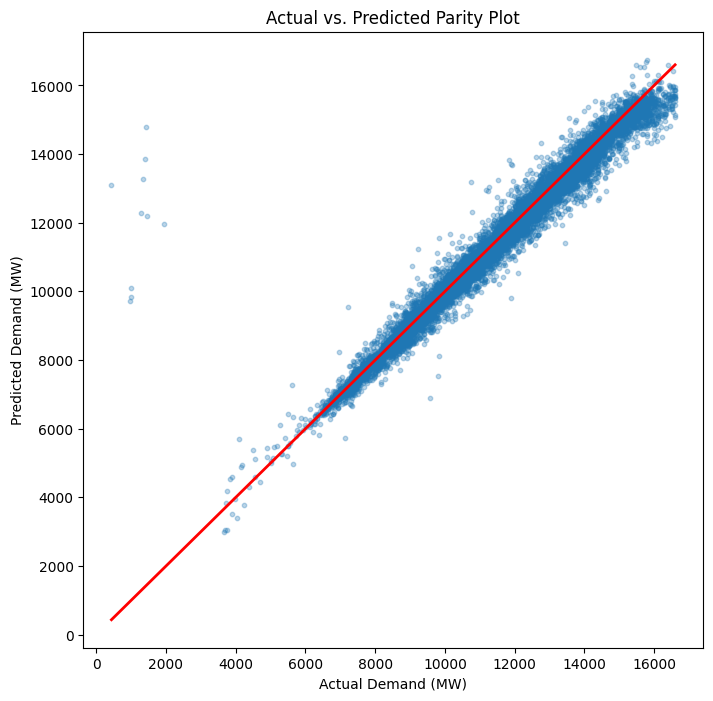

In [30]:
plt.figure(figsize=(8, 8))
y_test = y_val
y_pred = best_model.predict(X_val)
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Demand (MW)')
plt.ylabel('Predicted Demand (MW)')
plt.title('Actual vs. Predicted Parity Plot')
plt.savefig('parity_plot.png')

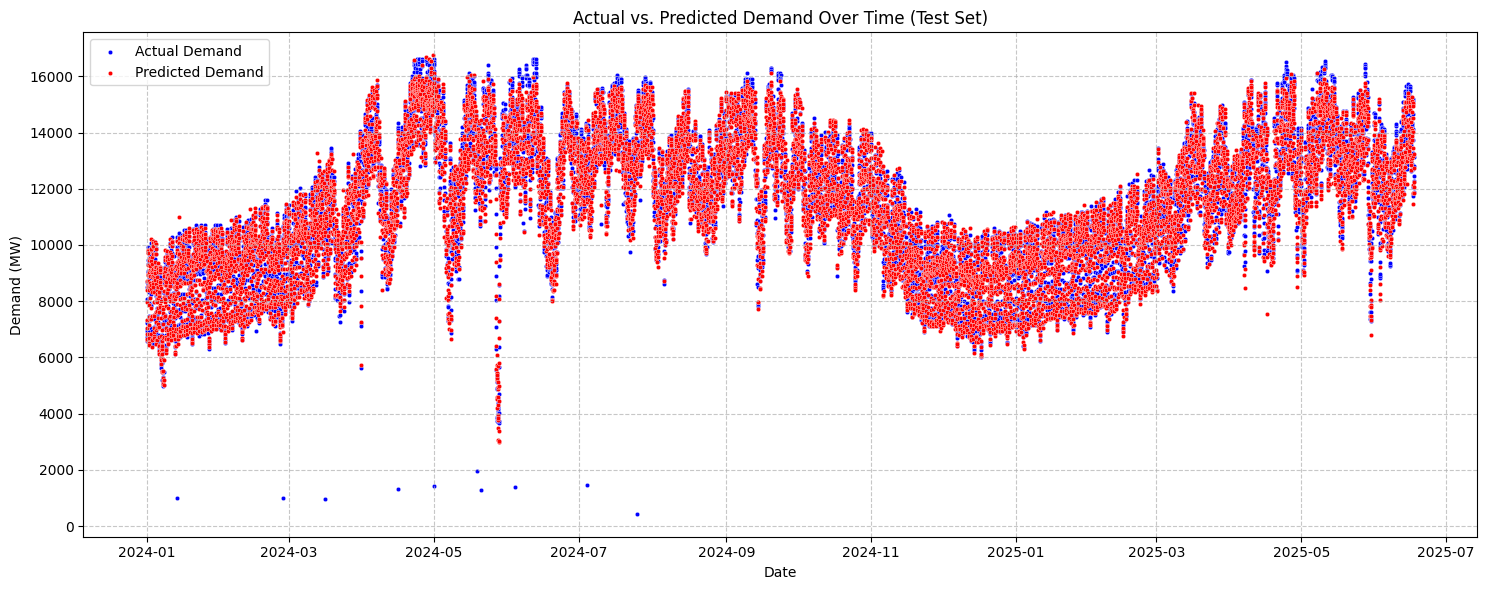

In [45]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x=y_test.index, y=y_test, label='Actual Demand', s=10,color='blue')
sns.scatterplot(x=y_test.index, y=y_pred, label='Predicted Demand',s=10, color='red')
plt.title('Actual vs. Predicted Demand Over Time (Test Set)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [32]:
mape_best_model = mean_absolute_percentage_error(y_val, y_pred)
print(f'MAPE for the best model: {mape_best_model:.2%}')

MAPE for the best model: 2.79%


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
mae_best_model = mean_absolute_error(y_val, y_pred)
print(f'MAE for the best model: {mae_best_model:.2f} MW')
print(f'RMSE for the best model: {np.sqrt(mean_squared_error(y_val, y_pred)):.2f} MW')

MAE for the best model: 239.89 MW
RMSE for the best model: 446.14 MW


In [46]:
y_val_week = y_val.head(7 * 24)
y_pred_week = pd.Series(y_pred[:7 * 24], index=y_val_week.index)

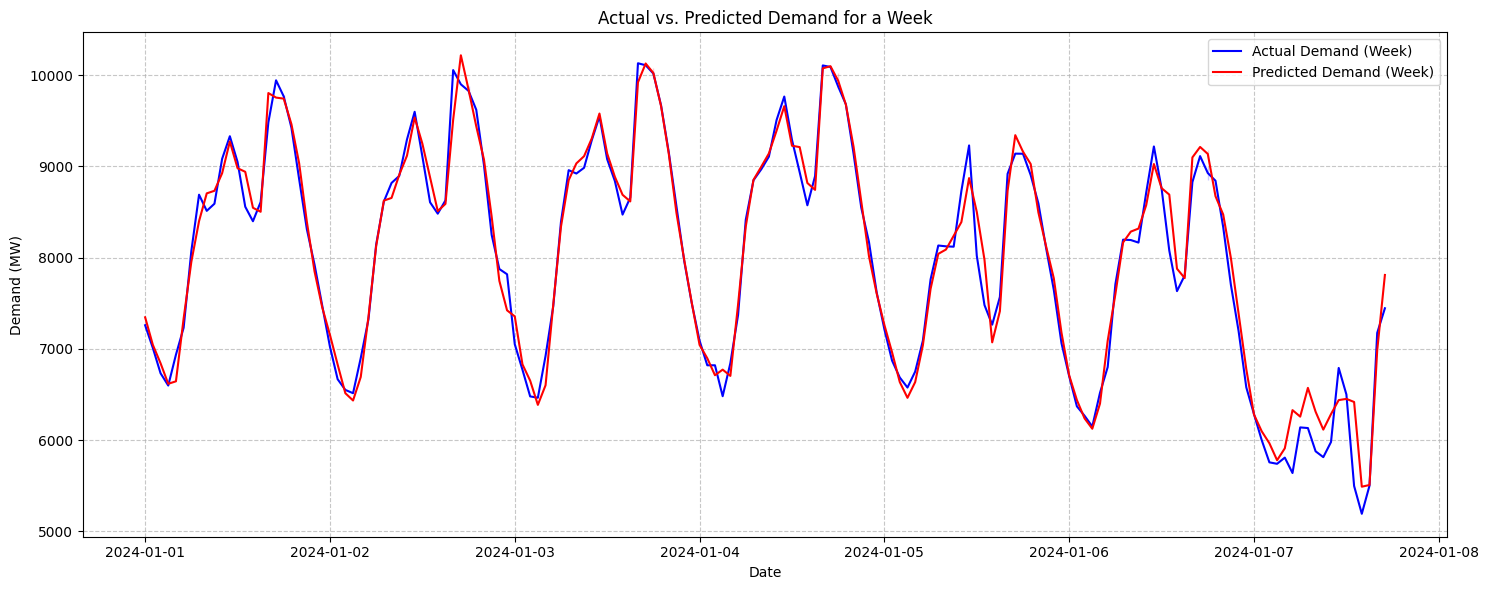

In [48]:
plt.figure(figsize=(15, 6))
sns.lineplot(x=y_val_week.index, y=y_val_week, label='Actual Demand (Week)', color='blue')
sns.lineplot(x=y_val_week.index, y=y_pred_week, label='Predicted Demand (Week)', color='red')
plt.title('Actual vs. Predicted Demand for a Week')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()